# Production-Ready OCR &
# Document Understanding
# Mastery Challenge

# Overview

- Research/Learn: OCR vs Document Understanding, supported document types(energy bills, passports, certificates, driverʼs licenses), schema-based extraction.
- Actions: Set up GCP project (Vertex AI, Cloud Storage), HF account, install core libraries.
- Milestone: Working environment with basic image/PDF loading and dummyinference test



## Step 1

## Research/Learn:
- OCR: Optical Character Recongnition technology is used to convert images of handwrite and typed text into editable and seachable document --> Image/PDF to text (TesseratORC, PaddleORC…)
- Document Understanding: Combining OCR with model AI about langue to classify document and extract information --> Image/PDF to Structured Data
- Support document types: Invoice, Passport, ID Card…


## Actions:
After setup GCP with Vertex AI, Cloud Storage and Login Hugging Face. Activate API:
- gcloud services enable: Requests activation of services for the project
- apiplatform.googleapis.com: Activate Vertex AI
- Storage-component.gooleapis.com: Activate GG Cloud Storage

In [ ]:
# !gcloud services enable aiplatform.googleapis.com storage-component.googleapis.com



and Intsall libraries:
- tesseract-ocr, libtessaeract-dev: Open-source ORC tool for character recogniton from images
- poppler-utils: convert PDF to IMG
- transformers, datasets, huggingface_hub: Load model, dataset and save the model on HF.

In [ ]:
# # Install packet
# !sudo apt-get update && sudo apt-get install -y tesseract-ocr libtesseract-dev poppler-utils

# # Install pythob lib
# !pip install --upgrade google-cloud-aiplatform google-cloud-storage \
#     transformers datasets huggingface_hub \
#     torch torchvision torchaudio \
#     pillow opencv-python pytesseract pdf2image python-dotenv

Login Hugging Face with token:

In [ ]:
# !hf auth login

## Milestone:


In [ ]:
%pip install -q pytesseract transformers datasets pillow torch torchvision

In [2]:
import PIL.Image
import pytesseract
from transformers import pipeline
import torch
import os

path = "invoice.jpg"  

if not os.path.exists(path):
    print(f"Lỗi: Không tìm thấy tệp {path}")
else:
    device = 0 if torch.cuda.is_available() else -1
    
    nlp = pipeline(
        "document-question-answering",
        model="impira/layoutlm-document-qa",
        device=device
    )


Loading weights:   0%|          | 0/205 [00:00<?, ?it/s]

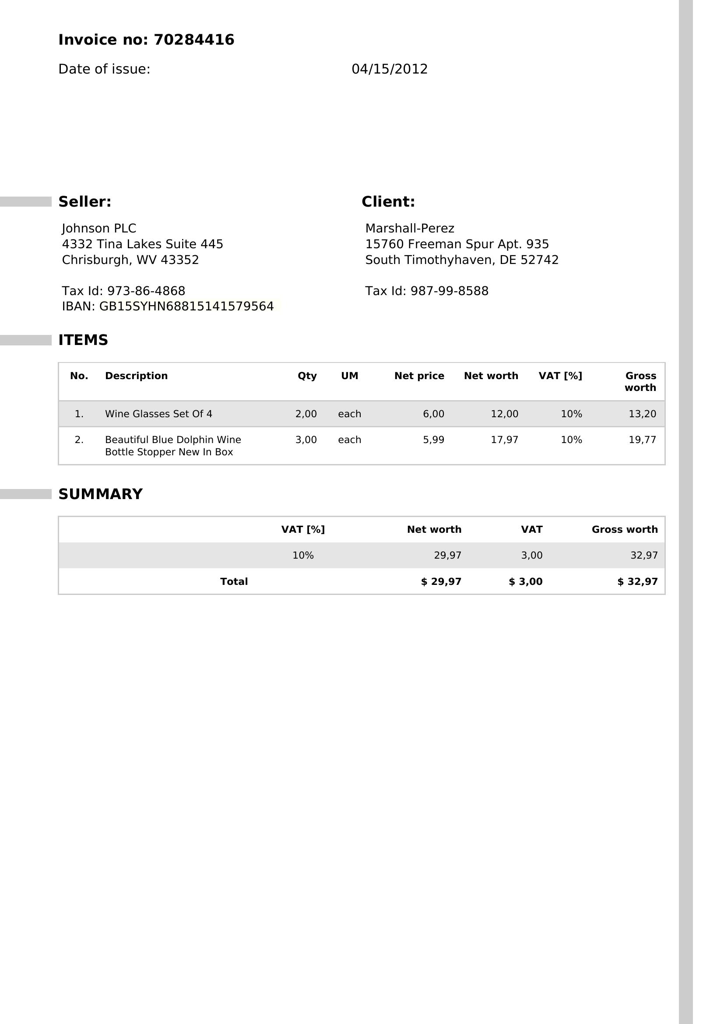

In [26]:
from IPython.display import display
from PIL import Image

img = Image.open(path)
max_size = (1024, 1024)
img.thumbnail(max_size)
display(img)


In [19]:
print("\n OCR:")
raw_text = pytesseract.image_to_string(PIL.Image.open(path), lang='vie+eng')
print(raw_text)



 OCR:
Invoice no: 70284416

Date of issue:

Seller:

Johnson PLC
4332 Tina Lakes Suite 445
Chrisburgh, WV 43352

Tax Id: 973-86-4868
IBAN: GB15SYHN68815141579564

ITEMS
No. Description Qty
il Wine Glasses Set Of 4 2,00
2. Beautiful Blue Dolphin Wine 3,00

Bottle Stopper New In Box

SUMMARY

VAT [%]

10%

Total

04/15/2012

Client:

Marshall-Perez
15760 Freeman Spur Apt. 935
South Timothyhaven, DE 52742

Tax Id: 987-99-8588

Net price

Net worth VAT [%]
each 6,00 12,00 10%
5,99 17,97 10%

Net worth VAT

29,97 3,00

$ 29,97 $ 3,00

Gross
worth

13,20

19,77

Gross worth
32,97

$ 32,97



In [25]:
questions = [
    "What is the total amount?",
    "What is the invoice number?",
    "What is the date?"
]

for question in questions:
    result = nlp(image=path, question=question)
    print(f"Ques: {question}")
    print(f"Answer: {result[0]['answer']} (Acc: {round(result[0]['score'], 4)})\n")


 Json
Ques: What is the total amount?
Answer: 10% (Acc: 0.0985)

Ques: What is the invoice number?
Answer: 70284416 (Acc: 0.9999)

Ques: What is the date?
Answer: 04/15/2012 (Acc: 0.9998)

